In [2]:
# Cell 1: Import necessary libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, Conv2DTranspose
from tensorflow.keras.layers import concatenate, BatchNormalization, Activation, Add
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import MeanIoU
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import Sequence

In [ ]:
# 2: Define constants and paths
IMAGE_DIR = "../data/MSFD/1/face_crop"
MASK_DIR = "../data/MSFD/1/face_crop_segmentation"
IMG_SIZE = (128, 128)
IMG_HEIGHT, IMG_WIDTH = 128, 128
BATCH_SIZE = 8
EPOCHS = 50
CHECKPOINT_PATH = "./checkpoints/unet_vgg19.h5"
MODEL_PATH = "./models/unet_vgg19_final.h5"

In [ ]:
# 3: Data loading function
def load_data(image_dir, mask_dir, img_size=(IMG_HEIGHT, IMG_WIDTH),limit=2500):
    images, masks = [], []
    image_files = sorted(os.listdir(image_dir))  # Ensure correct order
    mask_files = sorted(os.listdir(mask_dir))
    print(f"Found {len(image_files)} images and {len(mask_files)} masks")
    seen=0 
    for img_file, mask_file in zip(image_files, mask_files):
        if seen>limit:
            break
        seen+=1
        img_path = os.path.join(image_dir, img_file)
        mask_path = os.path.join(mask_dir, mask_file)
        
        if not os.path.exists(img_path) or not os.path.exists(mask_path):
            continue
            
        img = cv2.imread(img_path)
        if img is None:
            print(f"Warning: Could not read image {img_path}")
            continue
            
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB
        img = cv2.resize(img, img_size) / 255.0  # Normalize
        
        # Read and resize masks
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            print(f"Warning: Could not read mask {mask_path}")
            continue
            
        mask = cv2.resize(mask, img_size)
        mask = np.expand_dims(mask, axis=-1)  # Add channel dimension
        mask = mask / 255.0  # Convert to binary (0 or 1)
        mask = (mask > 0.5).astype(np.float32)  # Ensure binary values
        
        images.append(img)
        masks.append(mask)
    
    return np.array(images), np.array(masks)

In [ ]:
# 4: Data Generator class for loading batches
class DataGenerator(Sequence):
    def __init__(self, X, y, batch_size=BATCH_SIZE, shuffle=True):
        self.X = X
        self.y = y
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.X))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __len__(self):
        return int(np.ceil(len(self.X) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        X_batch = self.X[batch_indexes]
        y_batch = self.y[batch_indexes]
        return X_batch, y_batch
    
    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

In [ ]:
# 5: Load and split the dataset
X, Y = load_data(IMAGE_DIR, MASK_DIR,limit=2500)
print(f"Dataset loaded: {X.shape}, {Y.shape}")

# Split data into training and validation sets
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape}, {Y_train.shape}")
print(f"Validation set: {X_val.shape}, {Y_val.shape}")

# Create data generators
train_gen = DataGenerator(X_train, Y_train, batch_size=BATCH_SIZE)
val_gen = DataGenerator(X_val, Y_val, batch_size=BATCH_SIZE)

Found 9383 images and 9383 masks
Dataset loaded: (2501, 128, 128, 3), (2501, 128, 128, 1)
Training set: (2000, 128, 128, 3), (2000, 128, 128, 1)
Validation set: (501, 128, 128, 3), (501, 128, 128, 1)


In [ ]:
# 6: Define metrics - Dice coefficient and IoU
def dice_coef(y_true, y_pred, smooth=1):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def iou_coef(y_true, y_pred, smooth=1):
    intersection = tf.keras.backend.sum(tf.keras.backend.abs(y_true * y_pred), axis=[1, 2, 3])
    union = tf.keras.backend.sum(y_true, axis=[1, 2, 3]) + tf.keras.backend.sum(y_pred, axis=[1, 2, 3]) - intersection
    return tf.keras.backend.mean((intersection + smooth) / (union + smooth))

In [ ]:
#  Define the U-Net with VGG19 backbone
def build_unet_vgg19(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)):
    # Input tensor
    inputs = Input(input_shape)
    
    # VGG19 backbone (without top layer)
    vgg19 = VGG19(include_top=False, weights='imagenet', input_tensor=inputs)
    
    # Extract features from different levels of VGG19
    # Block 1
    s1 = vgg19.get_layer('block1_conv2').output  # 128x128
    
    # Block 2
    s2 = vgg19.get_layer('block2_conv2').output  # 64x64
    
    # Block 3
    s3 = vgg19.get_layer('block3_conv4').output  # 32x32
    
    # Block 4
    s4 = vgg19.get_layer('block4_conv4').output  # 16x16
    
    # Block 5 (bottleneck)
    s5 = vgg19.get_layer('block5_conv4').output  # 8x8
    
    # Decoder path
    # Bridge - further process the bottleneck features
    b1 = Conv2D(512, (3, 3), padding='same')(s5)
    b1 = BatchNormalization()(b1)
    b1 = Activation('relu')(b1)
    b1 = Dropout(0.3)(b1)
    b1 = Conv2D(512, (3, 3), padding='same')(b1)
    b1 = BatchNormalization()(b1)
    b1 = Activation('relu')(b1)
    
    # Decoder 1
    d1 = Conv2DTranspose(512, (3, 3), strides=(2, 2), padding='same')(b1)  # 16x16
    d1 = concatenate([d1, s4])
    d1 = Conv2D(512, (3, 3), padding='same')(d1)
    d1 = BatchNormalization()(d1)
    d1 = Activation('relu')(d1)
    d1 = Dropout(0.3)(d1)
    d1 = Conv2D(512, (3, 3), padding='same')(d1)
    d1 = BatchNormalization()(d1)
    d1 = Activation('relu')(d1)
    
    # Decoder 2
    d2 = Conv2DTranspose(256, (3, 3), strides=(2, 2), padding='same')(d1)  # 32x32
    d2 = concatenate([d2, s3])
    d2 = Conv2D(256, (3, 3), padding='same')(d2)
    d2 = BatchNormalization()(d2)
    d2 = Activation('relu')(d2)
    d2 = Dropout(0.3)(d2)
    d2 = Conv2D(256, (3, 3), padding='same')(d2)
    d2 = BatchNormalization()(d2)
    d2 = Activation('relu')(d2)
    
    # Decoder 3
    d3 = Conv2DTranspose(128, (3, 3), strides=(2, 2), padding='same')(d2)  # 64x64
    d3 = concatenate([d3, s2])
    d3 = Conv2D(128, (3, 3), padding='same')(d3)
    d3 = BatchNormalization()(d3)
    d3 = Activation('relu')(d3)
    d3 = Dropout(0.3)(d3)
    d3 = Conv2D(128, (3, 3), padding='same')(d3)
    d3 = BatchNormalization()(d3)
    d3 = Activation('relu')(d3)
    
    # Decoder 4
    d4 = Conv2DTranspose(64, (3, 3), strides=(2, 2), padding='same')(d3)  # 128x128
    d4 = concatenate([d4, s1])
    d4 = Conv2D(64, (3, 3), padding='same')(d4)
    d4 = BatchNormalization()(d4)
    d4 = Activation('relu')(d4)
    d4 = Dropout(0.3)(d4)
    d4 = Conv2D(64, (3, 3), padding='same')(d4)
    d4 = BatchNormalization()(d4)
    d4 = Activation('relu')(d4)
    
    # Output layer
    outputs = Conv2D(1, (1, 1), activation='sigmoid')(d4)
    
    # Create model
    model = Model(inputs=[inputs], outputs=[outputs])
    
    return model

In [ ]:
# 8: Build and compile model
model = build_unet_vgg19(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Compile model with custom metrics
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=dice_loss,
    metrics=[dice_coef, iou_coef, 'binary_accuracy']
)

# Display model summary
model.summary()

I0000 00:00:1743434399.778811    6550 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6292 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 128, 128,  │      1,792 │ input_layer[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 128, 128,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 64, 64,    │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 64, 64,    │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 64, 64,    │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 32, 32,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 32, 32,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 32, 32,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 32, 32,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv4        │ (None, 32, 32,    │    590,080 │ block3_conv3[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 16, 16,    │          0 │ block3_conv4[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 16, 16,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 16, 16,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 16, 16,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv4        │ (None, 16, 16,    │  2,359,808 │ block4_conv3[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 8, 8, 512) │          0 │ block4_conv4[0][

 Total params: 38,066,625 (145.21 MB)

 Trainable params: 38,060,737 (145.19 MB)

 Non-trainable params: 5,888 (23.00 KB)

In [ ]:
#  9 (Update): Update callbacks with new paths

# Create checkpoint directory if it doesn't exist
os.makedirs(os.path.dirname(CHECKPOINT_PATH), exist_ok=True)
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)

callbacks = [
    ModelCheckpoint(
        CHECKPOINT_PATH,
        monitor='val_dice_coef',
        verbose=1,
        save_best_only=True,
        mode='max'
    ),
    EarlyStopping(
        monitor='val_dice_coef',
        patience=10,
        verbose=1,
        mode='max'
    ),
    ReduceLROnPlateau(
        monitor='val_dice_coef',
        factor=0.1,
        patience=5,
        verbose=1,
        mode='max',
        min_lr=1e-7
    )
]


In [ ]:
# 10: Train the model
history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

# Save the final model
model.save(MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")

Epoch 1/50


/home/nira/miniconda3/envs/unet/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/home/nira/miniconda3/envs/unet/lib/python3.9/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 128, 128, 3))
  warnings.warn(msg)
I0000 00:00:1743434406.025758    7607 service.cc:152] XLA service 0x7095c0015320 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1743434406.025808    7607 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2025-03-31 20:50:06.21982

  1/250 ━━━━━━━━━━━━━━━━━━━━ 1:37:48 24s/step - binary_accuracy: 0.5671 - dice_coef: 0.3806 - iou_coef: 0.2299 - loss: 0.6194

I0000 00:00:1743434424.979235    7607 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - binary_accuracy: 0.7976 - dice_coef: 0.6680 - iou_coef: 0.5226 - loss: 0.3320
Epoch 1: val_dice_coef improved from -inf to 0.80834, saving model to ./checkpoints/unet_vgg19.h5


...

250/250 ━━━━━━━━━━━━━━━━━━━━ 39s 156ms/step - binary_accuracy: 0.8860 - dice_coef: 0.8277 - iou_coef: 0.7085 - loss: 0.1723 - val_binary_accuracy: 0.8745 - val_dice_coef: 0.8241 - val_iou_coef: 0.7024 - val_loss: 0.1759 - learning_rate: 1.0000e-04
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - binary_accuracy: 0.8884 - dice_coef: 0.8346 - iou_coef: 0.7199 - loss: 0.1654
Epoch 3: val_dice_coef improved from 0.82414 to 0.83035, saving model to ./checkpoints/unet_vgg19.h5


250/250 ━━━━━━━━━━━━━━━━━━━━ 39s 156ms/step - binary_accuracy: 0.8884 - dice_coef: 0.8346 - iou_coef: 0.7199 - loss: 0.1654 - val_binary_accuracy: 0.8792 - val_dice_coef: 0.8303 - val_iou_coef: 0.7125 - val_loss: 0.1699 - learning_rate: 1.0000e-04
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - binary_accuracy: 0.8908 - dice_coef: 0.8399 - iou_coef: 0.7279 - loss: 0.1601
Epoch 4: val_dice_coef did not improve from 0.83035
250/250 ━━━━━━━━━━━━━━━━━━━━ 38s 152ms/step - binary_accuracy: 0.8908 - dice_coef: 0.8399 - iou_coef: 0.7279 - loss: 0.1601 - val_binary_accuracy: 0.8871 - val_dice_coef: 0.8294 - val_iou_coef: 0.7162 - val_loss: 0.1709 - learning_rate: 1.0000e-04
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - binary_accuracy: 0.8893 - dice_coef: 0.8379 - iou_coef: 0.7259 - loss: 0.1621
Epoch 5: val_dice_coef improved from 0.83035 to 0.83790, saving model to ./checkpoints/unet_vgg19.h5


250/250 ━━━━━━━━━━━━━━━━━━━━ 39s 156ms/step - binary_accuracy: 0.8893 - dice_coef: 0.8380 - iou_coef: 0.7259 - loss: 0.1620 - val_binary_accuracy: 0.8893 - val_dice_coef: 0.8379 - val_iou_coef: 0.7289 - val_loss: 0.1620 - learning_rate: 1.0000e-04
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - binary_accuracy: 0.8967 - dice_coef: 0.8468 - iou_coef: 0.7390 - loss: 0.1532
Epoch 6: val_dice_coef did not improve from 0.83790
250/250 ━━━━━━━━━━━━━━━━━━━━ 38s 151ms/step - binary_accuracy: 0.8967 - dice_coef: 0.8468 - iou_coef: 0.7390 - loss: 0.1532 - val_binary_accuracy: 0.8740 - val_dice_coef: 0.8273 - val_iou_coef: 0.7093 - val_loss: 0.1726 - learning_rate: 1.0000e-04
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - binary_accuracy: 0.8944 - dice_coef: 0.8469 - iou_coef: 0.7401 - loss: 0.1531
Epoch 7: val_dice_coef did not improve from 0.83790
250/250 ━━━━━━━━━━━━━━━━━━━━ 38s 152ms/step - binary_accuracy: 0.8944 - dice_coef: 0.8469 - iou_coef: 0.7401 - loss: 0.1531 - val_bi


Epoch 10: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-06.
250/250 ━━━━━━━━━━━━━━━━━━━━ 39s 156ms/step - binary_accuracy: 0.9010 - dice_coef: 0.8553 - iou_coef: 0.7522 - loss: 0.1447 - val_binary_accuracy: 0.8879 - val_dice_coef: 0.8379 - val_iou_coef: 0.7277 - val_loss: 0.1622 - learning_rate: 1.0000e-04
Epoch 11/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - binary_accuracy: 0.9064 - dice_coef: 0.8612 - iou_coef: 0.7633 - loss: 0.1388
Epoch 11: val_dice_coef did not improve from 0.83792
250/250 ━━━━━━━━━━━━━━━━━━━━ 38s 151ms/step - binary_accuracy: 0.9064 - dice_coef: 0.8612 - iou_coef: 0.7633 - loss: 0.1388 - val_binary_accuracy: 0.8884 - val_dice_coef: 0.8379 - val_iou_coef: 0.7283 - val_loss: 0.1616 - learning_rate: 1.0000e-05
Epoch 12/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - binary_accuracy: 0.9077 - dice_coef: 0.8659 - iou_coef: 0.7700 - loss: 0.1341
Epoch 12: val_dice_coef did not improve from 0.83792
250/250 ━━━━━━━━━━━━━━━━━━━━ 38s 152ms/step - bina

Model saved to ./models/unet_vgg19_final.h5


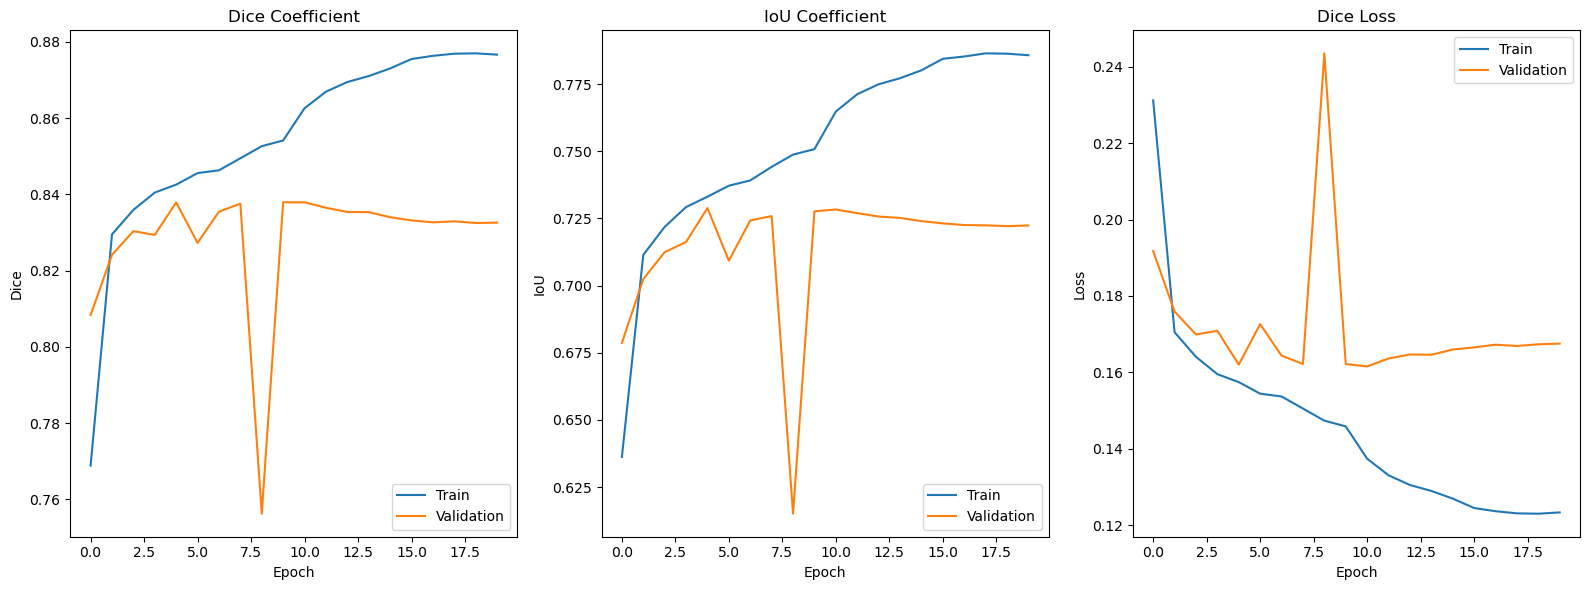

In [ ]:
# 11: Plot training history
plt.figure(figsize=(16, 6))

# Plot Dice coefficient
plt.subplot(1, 3, 1)
plt.plot(history.history['dice_coef'])
plt.plot(history.history['val_dice_coef'])
plt.title('Dice Coefficient')
plt.ylabel('Dice')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')

# Plot IoU
plt.subplot(1, 3, 2)
plt.plot(history.history['iou_coef'])
plt.plot(history.history['val_iou_coef'])
plt.title('IoU Coefficient')
plt.ylabel('IoU')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')

# Plot Loss
plt.subplot(1, 3, 3)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Dice Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
# 12 (Update): Update model loading path for evaluation
# Load the best model
best_model = tf.keras.models.load_model(CHECKPOINT_PATH, custom_objects={
    'dice_loss': dice_loss,
    'dice_coef': dice_coef,
    'iou_coef': iou_coef
})

# Evaluate on validation set
val_results = best_model.evaluate(val_gen)
print(f'Validation Dice Loss: {val_results[0]:.4f}')
print(f'Validation Dice Coef: {val_results[1]:.4f}')
print(f'Validation IoU: {val_results[2]:.4f}')
print(f'Validation Accuracy: {val_results[3]:.4f}')

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - binary_accuracy: 0.8847 - dice_coef: 0.8330 - iou_coef: 0.7176 - loss: 0.1670
Validation Dice Loss: 0.1619
Validation Dice Coef: 0.8374
Validation IoU: 0.7269
Validation Accuracy: 0.8879


In [ ]:
# 13:  function to visualize segmentation results
def visualize_prediction(model, img_idx, images=X_val, masks=Y_val):
    # Get sample image and mask
    img = images[img_idx]
    true_mask = masks[img_idx]
    
    # Predict mask
    pred_mask = model.predict(np.expand_dims(img, axis=0))[0]
    
    # Convert to binary
    pred_mask_binary = (pred_mask > 0.5).astype(np.uint8)
    
    # Calculate metrics
    dice = dice_coef(true_mask, pred_mask_binary).numpy()
    iou = iou_coef(true_mask, pred_mask_binary).numpy()
    
    # Visualize
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    
    ax[0].imshow(img)
    ax[0].set_title('Original Image')
    ax[0].axis('off')
    
    ax[1].imshow(true_mask[:,:,0], cmap='gray')
    ax[1].set_title('True Mask')
    ax[1].axis('off')
    
    ax[2].imshow(pred_mask[:,:,0], cmap='gray')
    ax[2].set_title(f'Predicted Mask\nDice: {dice:.4f}, IoU: {iou:.4f}')
    ax[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    return dice, iou

# Visualize a few examples
for i in range(5):  # Show 5 random examples
    idx = np.random.randint(0, len(X_val))
    print(f"Sample {i+1}, Image Index: {idx}")
    visualize_prediction(best_model, idx)

In [ ]:
# 14: Inference - Function for making predictions on new images
def predict_mask(model, image_path, threshold=0.5):
    # Read and preprocess the image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT)) / 255.0
    
    # Predict mask
    pred_mask = model.predict(np.expand_dims(img_resized, axis=0))[0]
    pred_mask_binary = (pred_mask > threshold).astype(np.uint8) * 255
    
    # Resize mask back to original image size
    original_h, original_w = img.shape[:2]
    pred_mask_original_size = cv2.resize(pred_mask_binary, (original_w, original_h))
    
    # Visualize
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    
    ax[0].imshow(img)
    ax[0].set_title('Original Image')
    ax[0].axis('off')
    
    ax[1].imshow(img_resized)
    ax[1].set_title('Resized Image (Model Input)')
    ax[1].axis('off')
    
    ax[2].imshow(pred_mask[:,:,0], cmap='gray')
    ax[2].set_title('Predicted Mask')
    ax[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return pred_mask_original_size

In [ ]:
# 15: Run inference on a new image
# Replace this with a path to a new image you want to test
new_image_path = "../data/MSFD/1/face_crop/some_new_image.jpg"  # Change to actual path

try:
    # Check if file exists
    if os.path.exists(new_image_path):
        # Run inference
        predicted_mask = predict_mask(best_model, new_image_path)
        
        # Save the predicted mask
        output_path = "predicted_mask.png"
        cv2.imwrite(output_path, predicted_mask)
        print(f"Prediction saved to {output_path}")
    else:
        print(f"Image not found at {new_image_path}")
        print("You can use any image from your dataset or a new image by changing the 'new_image_path' variable.")
        
        # Alternatively, use a random image from the validation set for demo
        rand_idx = np.random.randint(0, len(X_val))
        print(f"Using a random image from validation set (index: {rand_idx})")
        visualize_prediction(best_model, rand_idx)
except Exception as e:
    print(f"Error during inference: {e}")

In [ ]:
#  Calculate metrics on the entire validation set
def calculate_metrics_on_dataset(model, images, masks, batch_size=BATCH_SIZE):
    dice_scores = []
    iou_scores = []
    
    # Process in batches to avoid memory issues
    num_samples = len(images)
    num_batches = int(np.ceil(num_samples / batch_size))
    
    for i in range(num_batches):
        start_idx = i * batch_size
        end_idx = min((i + 1) * batch_size, num_samples)
        
        batch_images = images[start_idx:end_idx]
        batch_masks = masks[start_idx:end_idx]
        
        # Predict masks
        pred_masks = model.predict(batch_images)
        pred_masks_binary = (pred_masks > 0.5).astype(np.float32)
        
        # Calculate metrics for each image
        for j in range(len(batch_images)):
            true_mask = batch_masks[j]
            pred_mask = pred_masks_binary[j]
            
            # Calculate Dice
            dice = dice_coef(true_mask, pred_mask).numpy()
            dice_scores.append(dice)
            
            # Calculate IoU
            iou = iou_coef(true_mask, pred_mask).numpy()
            iou_scores.append(iou)
    
    # Calculate average metrics
    avg_dice = np.mean(dice_scores)
    avg_iou = np.mean(iou_scores)
    
    return avg_dice, avg_iou, dice_scores, iou_scores

# Calculate metrics on validation set
avg_dice, avg_iou, all_dice_scores, all_iou_scores = calculate_metrics_on_dataset(best_model, X_val, Y_val)

print(f"Average Dice Coefficient: {avg_dice:.4f}")
print(f"Average IoU: {avg_iou:.4f}")

# Plot distribution of scores
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(all_dice_scores, bins=20, alpha=0.7)
plt.axvline(avg_dice, color='r', linestyle='--', label=f'Mean: {avg_dice:.4f}')
plt.title('Distribution of Dice Coefficients')
plt.xlabel('Dice Coefficient')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(all_iou_scores, bins=20, alpha=0.7)
plt.axvline(avg_iou, color='r', linestyle='--', label=f'Mean: {avg_iou:.4f}')
plt.title('Distribution of IoU Scores')
plt.xlabel('IoU Score')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()